In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from gstools import SRF, Gaussian
from gstools.random import MasterRNG

In [3]:
from scipy import integrate

In [4]:
m = 100
n = 110

In [5]:
x = np.linspace(0, 1, m)

In [6]:
seed = MasterRNG(45)
def one_function(x):
    model = Gaussian(dim = 1, var = 3, len_scale = 0.3)
    srf = SRF(model, seed=seed())
    f = srf.structured([x])
    return f

In [7]:
U = np.zeros((m, n))
for i in range(m):
    U[:, i] = one_function(x)

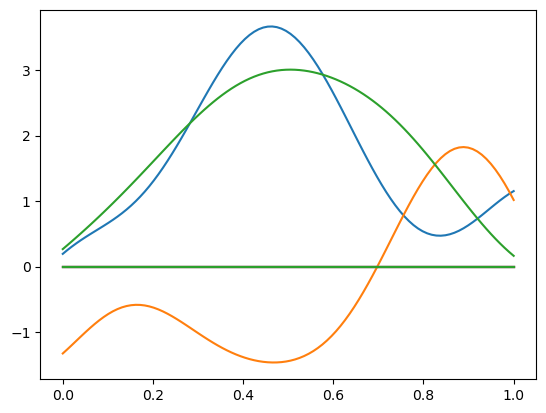

In [8]:
plt.plot(x, U[:, 97:])

In [9]:
def integrate_one_function(f):
    result = np.zeros_like(f)
    result[0] = 0
    for i in range(1, len(f)):
        result[i] = integrate.simps(f[:i+1], x[:i+1])
    return result

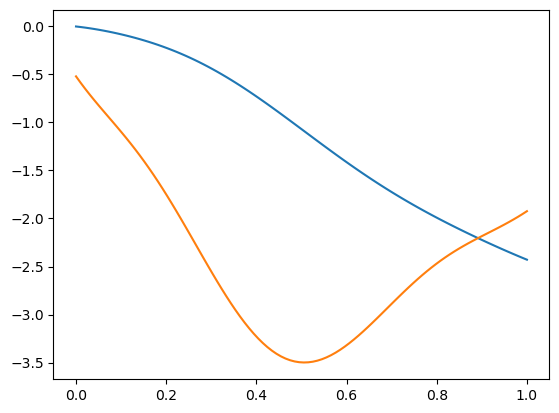

In [10]:
f = U[:, 3]
f_int = integrate_one_function(f)
plt.plot(x, f_int)
plt.plot(x, f)

In [11]:
S = np.zeros((m,n))
for i in range(n):
    S[:, i] = integrate_one_function(U[:, i])

In [13]:
# US -> m*n = 11000 ==> us (11000,100)
# xs -> (11000, 1)#m = 100
#n = 110

#def integrate_data(m=m, n=n, x=x, U=U, S=S):
# ss -> (11000, 1)

In [14]:
#m = 100
#n = 110

def integrate_data(m=m, n=n, x=x, U=U, S=S):
    us = np.zeros((m*n, m))
    xs = np.zeros((m*n, 1))
    ss = np.zeros((m*n, 1))
    for i in range(n):
        for j in range(m):
            us[i*m+j, :] = U[:, i]
            xs[i*m+j, :] = x[j]
            ss[i*m+j, :] = S[j, i]
    return us, xs, ss

In [15]:
us, xs, ss = integrate_data()
print(us.shape, xs.shape, ss.shape)

(11000, 100) (11000, 1) (11000, 1)


In [16]:
def batch_dataset(batch_size, m=m, n=n, x=x, U=U, S=S, ratio=0.9):
    us, xs, ss = integrate_data(m, n, x, U, S)
    train_size = int(len(us)*ratio)
    us_train = us[:train_size]
    xs_train = xs[:train_size]
    ss_train = ss[:train_size]

    us_test = us[train_size:]
    xs_test = xs[train_size:]
    ss_test = ss[train_size:]

    us_train = torch.tensor(us_train, dtype=torch.float32)
    xs_train = torch.tensor(xs_train, dtype=torch.float32)
    ss_train = torch.tensor(ss_train, dtype=torch.float32)
    train_dataset = torch.utils.data.TensorDataset(us_train, xs_train, ss_train)
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    us_test = torch.tensor(us_test, dtype=torch.float32)
    xs_test = torch.tensor(xs_test, dtype=torch.float32)
    ss_test = torch.tensor(ss_test, dtype=torch.float32)
    test_dataset = torch.utils.data.TensorDataset(us_test, xs_test, ss_test)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    return train_dataloader, test_dataloader

In [17]:
train_data, test_data = batch_dataset(batch_size=32, ratio=0.9)

In [18]:
for u_batch, x_batch, s_batch in train_data:
    print(u_batch, x_batch, s_batch)

tensor([[-0.2559, -0.2123, -0.1636,  ..., -1.1659, -1.2007, -1.2241],
        [ 0.9199,  0.8523,  0.7748,  ..., -1.0328, -1.0449, -1.0591],
        [-1.0485, -1.0421, -1.0360,  ..., -1.2039, -1.0814, -0.9627],
        ...,
        [-0.5196, -0.5855, -0.6483,  ..., -1.9835, -1.9544, -1.9239],
        [ 0.4276,  0.4049,  0.3810,  ..., -0.8224, -0.8780, -0.9361],
        [-0.5196, -0.5855, -0.6483,  ..., -1.9835, -1.9544, -1.9239]]) tensor([[0.5859],
        [0.7677],
        [0.9192],
        [0.5152],
        [0.6061],
        [0.6970],
        [0.9899],
        [0.1919],
        [0.5152],
        [0.8384],
        [0.6465],
        [0.8788],
        [0.9091],
        [0.6364],
        [0.3030],
        [0.2121],
        [0.5657],
        [0.9596],
        [0.0606],
        [0.6364],
        [0.1616],
        [0.5657],
        [0.6768],
        [0.7879],
        [0.9192],
        [0.9394],
        [0.0808],
        [0.4747],
        [0.9697],
        [0.4949],
        [0.1010],
        

In [19]:
class DeepONet(nn.Module):
    def __init__(self, neurons=40, in1=1, in2=1, output_neurons=20):
        super(DeepONet, self).__init__()
        self.in1 = in1
        self.in2 = in2
        self.output_neurons = output_neurons
        self.neurons = neurons

        self.branch = self.branch_network()
        self.trunk = self.trunk_network()

    def branch_network(self):
        branch = nn.Sequential(nn.Linear(self.in1, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.output_neurons))
        return branch


    def trunk_network(self):
        trunk = nn.Sequential(nn.Linear(self.in2, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.output_neurons))
        return trunk


    def forward(self, x1, x2):
        x1 = self.branch(x1)
        x2 = self.trunk(x2)
        x = torch.einsum("bi, bi-> b", x1, x2)
        x = torch.unsqueeze(x, 1)
        return x


In [20]:
x1 = torch.tensor([[1,2],
                  [3,4],
                  [5,6]])
print(x1.shape)


x2 = torch.tensor([[2,3],
                  [4,5],
                  [6,7]])
print(x2.shape)


torch.Size([3, 2])
torch.Size([3, 2])


In [21]:
result = torch.einsum("bi, bi -> b", x1, x2)
print(result)

tensor([ 8, 32, 72])


In [22]:
result = torch.einsum("bi, bi -> i", x1, x2)
print(result)

tensor([44, 68])


In [23]:
x1 = torch.tensor([[1,2,3,4]])
print(x1.shape)
x2 = torch.tensor([[1,2,3,4]])
print(x2.shape)
result = torch.einsum("bi, bi -> b", x1, x2)
print(result)


torch.Size([1, 4])
torch.Size([1, 4])
tensor([30])


In [24]:
model = DeepONet(neurons = 40, in1 = m, in2=1)

In [25]:
model.eval()

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=100, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=20, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=1, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): ReLU()
    (6): Linear(in_features=40, out_features=20, bias=True)
  )
)

In [26]:
def loss(y_pred, y):
    return torch.mean((y_pred - y)**2)

In [27]:
optimizer = torch.optim.Adam(model.parameters(), lr=.001)

In [28]:
train_losses = []
epochs = 2000
for i in range(epochs):
    l_total = 0
    for u_batch, x_batch, s_batch in train_data:
        model.train()
        optimizer.zero_grad()
        y_pred = model(u_batch, x_batch)

        l = loss(y_pred, s_batch)
        l_total += l.item()
        l.backward()
        optimizer.step()

    l_total = l_total/len(train_data)
    train_losses.append(l_total)

    if i%20 == 0:
        print("Epoch:  ", i, "/", epochs, "loss: ", l_total)

    

Epoch:   0 / 2000 loss:  0.050298288417229005
Epoch:   20 / 2000 loss:  0.000920380447097423
Epoch:   40 / 2000 loss:  0.00027261597769533943
Epoch:   60 / 2000 loss:  0.0005255649958862998
Epoch:   80 / 2000 loss:  0.0002503016474468994
Epoch:   100 / 2000 loss:  0.0006412331868153659
Epoch:   120 / 2000 loss:  0.0002682606644215881
Epoch:   140 / 2000 loss:  0.00011307988838046684
Epoch:   160 / 2000 loss:  0.0001737546417526544
Epoch:   180 / 2000 loss:  0.00026462369901456706
Epoch:   200 / 2000 loss:  0.0003088171780437997
Epoch:   220 / 2000 loss:  4.485301781847562e-05
Epoch:   240 / 2000 loss:  0.00019816385896950623
Epoch:   260 / 2000 loss:  0.00010988731054596663
Epoch:   280 / 2000 loss:  0.00019784600695974433
Epoch:   300 / 2000 loss:  0.0001429921590604335
Epoch:   320 / 2000 loss:  9.038964144858783e-05
Epoch:   340 / 2000 loss:  0.00011578665108836797
Epoch:   360 / 2000 loss:  0.0002298077435097507
Epoch:   380 / 2000 loss:  6.514942461440261e-05
Epoch:   400 / 2000 l

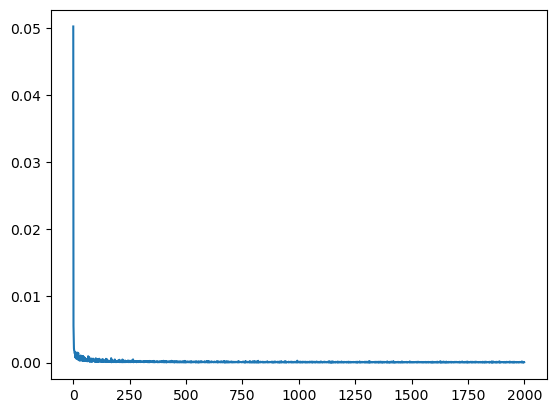

In [29]:
plt.plot(train_losses)

In [30]:
my_func = lambda x: np.cos(5*x)

In [31]:
inter_my_func = lambda  x:(1/5)*np.sin(5*x)

In [32]:
u_t = my_func(x)
s_t = inter_my_func(x)

In [33]:
model.eval()

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=100, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=20, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=1, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): ReLU()
    (6): Linear(in_features=40, out_features=20, bias=True)
  )
)

In [34]:
u_t_tens = torch.tensor(u_t, dtype = torch.float32)
#print(u_t_tens)
u_t_tens = torch.tensor(u_t, dtype = torch.float32).unsqueeze(0)
#print(u_t_tens)
x_tens = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
#print(x_tens)

In [35]:
print(u_t_tens.shape)

torch.Size([1, 100])


In [36]:
p = model(u_t_tens, x_tens)

In [37]:
print(u_t_tens)

tensor([[ 1.0000,  0.9987,  0.9949,  0.9885,  0.9797,  0.9683,  0.9544,  0.9382,
          0.9195,  0.8985,  0.8752,  0.8496,  0.8219,  0.7921,  0.7603,  0.7265,
          0.6909,  0.6535,  0.6145,  0.5739,  0.5318,  0.4883,  0.4437,  0.3979,
          0.3510,  0.3033,  0.2548,  0.2057,  0.1560,  0.1060,  0.0556,  0.0051,
         -0.0453, -0.0957, -0.1459, -0.1956, -0.2449, -0.2935, -0.3414, -0.3884,
         -0.4344, -0.4793, -0.5230, -0.5654, -0.6063, -0.6457, -0.6834, -0.7194,
         -0.7536, -0.7858, -0.8160, -0.8441, -0.8701, -0.8939, -0.9154, -0.9345,
         -0.9513, -0.9657, -0.9775, -0.9869, -0.9938, -0.9982, -0.9999, -0.9992,
         -0.9959, -0.9900, -0.9817, -0.9708, -0.9575, -0.9417, -0.9235, -0.9029,
         -0.8801, -0.8550, -0.8277, -0.7983, -0.7669, -0.7335, -0.6983, -0.6613,
         -0.6225, -0.5822, -0.5405, -0.4973, -0.4529, -0.4073, -0.3606, -0.3131,
         -0.2647, -0.2157, -0.1662, -0.1162, -0.0659, -0.0154,  0.0351,  0.0855,
          0.1357,  0.1855,  

In [38]:
p=p.detach().numpy()

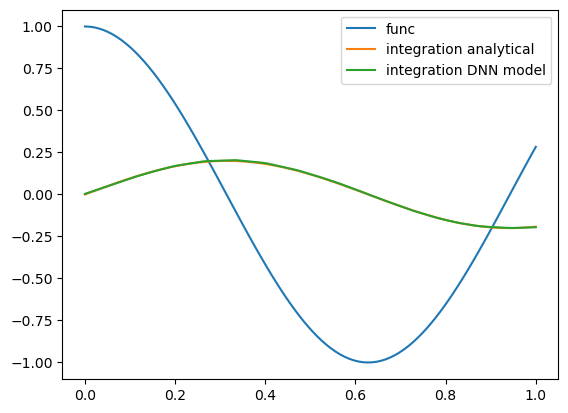

In [39]:
plt.plot(x, u_t, label = "func")
plt.plot(x, s_t, label = "integration analytical")
plt.plot(x, p, label = "integration DNN model")
plt.legend()

In [40]:
p

array([[ 0.00341071],
       [ 0.01261574],
       [ 0.02182076],
       [ 0.03102582],
       [ 0.04023086],
       [ 0.04943592],
       [ 0.05861529],
       [ 0.06777842],
       [ 0.0769416 ],
       [ 0.08610474],
       [ 0.09526789],
       [ 0.10443103],
       [ 0.11283646],
       [ 0.1207212 ],
       [ 0.12860598],
       [ 0.13649072],
       [ 0.14376286],
       [ 0.15077168],
       [ 0.1577805 ],
       [ 0.16478927],
       [ 0.17070112],
       [ 0.17521597],
       [ 0.17959338],
       [ 0.18397081],
       [ 0.18834822],
       [ 0.19272563],
       [ 0.19694518],
       [ 0.19890325],
       [ 0.19977179],
       [ 0.20064034],
       [ 0.20150888],
       [ 0.20237741],
       [ 0.20324598],
       [ 0.2045716 ],
       [ 0.20220135],
       [ 0.1995345 ],
       [ 0.19686772],
       [ 0.19420083],
       [ 0.191534  ],
       [ 0.18886718],
       [ 0.18488187],
       [ 0.1787848 ],
       [ 0.17268766],
       [ 0.16659057],
       [ 0.16049346],
       [ 0